## Task 1: Recreating Example 5.1 (Finding the Quantiles)

In **Example 5.1** of your textbook, we are given 12 measurements of a random variable and asked to test them against a hypothesized Normal distribution: $\mathcal{N}(\mu=0.4, \sigma^2=6.25)$. Note that a variance of $6.25$ means the standard deviation is $\sigma = 2.5$.

*Fun Fact: If you look closely at the textbook's manual sorting of the array, they made a mistake! They included `-1.23` which wasn't in the raw data, and forgot `1.01`! Today, we will trust our code to do it right.*

**Your Goal:**
1. Sort the raw data array.
2. We want $m=6$ quantiles, which means we need $m-1 = 5$ points. According to the book, the indices are $(n \cdot i/m)$. In 0-indexed Python, extract the 2nd, 4th, 6th, 8th, and 10th elements (indices `1, 3, 5, 7, 9`). These are your **Sample Quantiles**.
3. Use `scipy.stats.norm.ppf()` to calculate the **Theoretical Quantiles** for the probabilities $[1/6, 2/6, 3/6, 4/6, 5/6]$ using the hypothesized mean and standard deviation.
4. Use `scipy.stats.norm.cdf()` to calculate the **Theoretical Probabilities** for your extracted Sample Quantiles.

In [1]:
import numpy as np
import scipy.stats as stats

# The raw data from Example 5.1
x = np.array([1.15, 1.01, 3.24, -2.92, 0.3, 0.02, 1.14, 1.13, 1.23, 0.44, 0.17, 1.76])

# Hypothesized distribution parameters
mu_hyp = 0.4
sigma_hyp = np.sqrt(6.25)  # 2.5

# 1. Sort the data
x_sorted = np.sort(x)
print(f"Correctly Sorted Data: {x_sorted}\n")

# 2. Extract Sample Quantiles (indices 1, 3, 5, 7, 9)
sample_quantiles = x_sorted[[1, 3, 5, 7, 9]]
print(f"Sample Quantiles: {sample_quantiles}")

# 3. Calculate Theoretical Quantiles using the inverse CDF (PPF)
empirical_probs = np.array([1 / 6, 2 / 6, 3 / 6, 4 / 6, 5 / 6])
theo_quantiles = stats.norm.ppf(empirical_probs, loc=mu_hyp, scale=sigma_hyp)
print(f"Theoretical Quantiles: {np.round(theo_quantiles, 2)}")

# 4. Calculate Theoretical Probabilities for the sample points using the CDF
theo_probs = stats.norm.cdf(sample_quantiles, loc=mu_hyp, scale=sigma_hyp)
print(f"Theoretical Probabilities: {np.round(theo_probs, 2)}")

Correctly Sorted Data: [-2.92  0.02  0.17  0.3   0.44  1.01  1.13  1.14  1.15  1.23  1.76  3.24]

Sample Quantiles: [0.02 0.3  1.01 1.14 1.23]
Theoretical Quantiles: [-2.02 -0.68  0.4   1.48  2.82]
Theoretical Probabilities: [0.44 0.48 0.6  0.62 0.63]


---
## Task 2: Building the Q-Q and P-P Plots (Programming)

Now that we have all the coordinates, let's visualize them. 

A perfectly fitting theoretical distribution will result in points that fall exactly on the $y = x$ diagonal line ($45^\circ$ angle). 

**Your Goal:**
Create a side-by-side Plotly figure containing:
1. **Q-Q Plot:** Scatter plot of `Theoretical Quantiles` (x-axis) vs `Sample Quantiles` (y-axis).
2. **P-P Plot:** Scatter plot of `Empirical Probabilities` (x-axis) vs `Theoretical Probabilities` (y-axis).
3. Overlay a solid $y=x$ reference line on both plots to visually evaluate the fit!

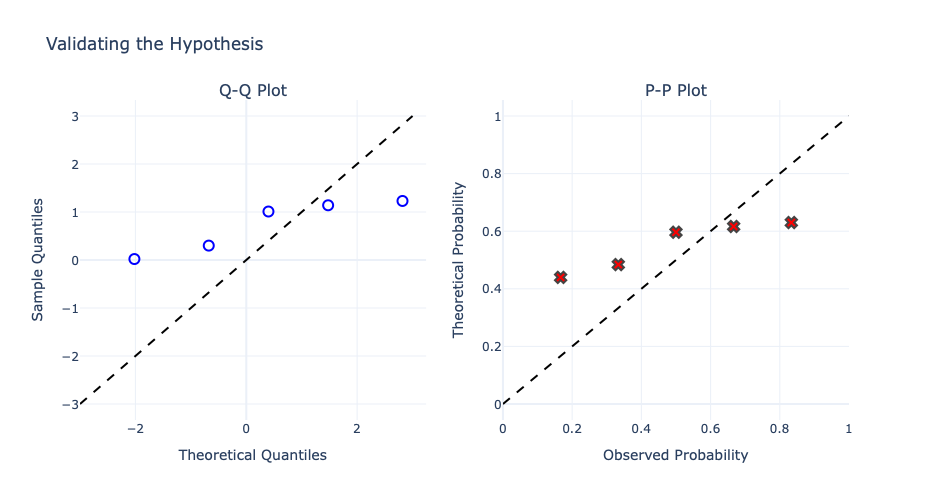

In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=2, subplot_titles=("Q-Q Plot", "P-P Plot"))

# --- 1. Q-Q Plot ---
# Add the scatter points
fig.add_trace(
    go.Scatter(
        x=theo_quantiles,
        y=sample_quantiles,
        mode="markers",
        marker=dict(size=10, color="blue", symbol="circle-open", line_width=2),
        name="Quantiles",
    ),
    row=1,
    col=1,
)

# Add the y=x reference line
fig.add_trace(
    go.Scatter(
        x=[-3, 3],
        y=[-3, 3],
        mode="lines",
        line=dict(color="black", dash="dash"),
        name="y=x Reference",
    ),
    row=1,
    col=1,
)

# --- 2. P-P Plot ---
# Add the scatter points
fig.add_trace(
    go.Scatter(
        x=empirical_probs,
        y=theo_probs,
        mode="markers",
        marker=dict(size=10, color="red", symbol="x", line_width=2),
        name="Probabilities",
    ),
    row=1,
    col=2,
)

# Add the y=x reference line
fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode="lines",
        line=dict(color="black", dash="dash"),
        showlegend=False,
    ),
    row=1,
    col=2,
)

fig.update_layout(
    height=500,
    width=900,
    title_text="Validating the Hypothesis",
    # title_text=r"Validating the $mathcal{N}(0.4, 6.25)$ Hypothesis",
    # title_text=r"$\mathcal{N}(0.4, 6.25)$",
    template="plotly_white",
    showlegend=False,
)

# Update axis labels
fig.update_xaxes(title_text="Theoretical Quantiles", row=1, col=1)
fig.update_yaxes(title_text="Sample Quantiles", row=1, col=1)
fig.update_xaxes(title_text="Observed Probability", row=1, col=2)
fig.update_yaxes(title_text="Theoretical Probability", row=1, col=2)

fig.show()

---
## 💡 Optional Visual Aid: Interactive Model Fitting

*Note: This section is purely an interactive visualization to help you build intuition!*

As you saw in Task 2, $\mathcal{N}(0.4, 6.25)$ is a bad fit for our data because the points deviate wildly from the diagonal line. But what does a *good* fit look like?

If we instead model the distribution using the **actual Sample Mean** ($\approx 0.85$) and the **actual Sample Variance** ($\approx 1.87$), the data should align perfectly.

Run the cell below and drag the slider from **"Bad Fit"** to **"Optimal Fit"**. Watch how tweaking the $\mu$ and $\sigma$ parameters dynamically pulls the points directly onto the $y=x$ line!

In [25]:
import ipywidgets as widgets
import numpy as np
import plotly.graph_objects as go
import scipy.stats as stats
from IPython.display import display
from plotly.subplots import make_subplots

# 1. Generate a "perfect" hidden dataset using an asymmetric Log-Normal distribution
np.random.seed(42)
hidden_s = 0.5  # Shape parameter (controls skewness/asymmetry)
hidden_scale = 6.0  # Scale parameter (controls stretch)
x_nice = stats.lognorm.rvs(s=hidden_s, scale=hidden_scale, size=100)
x_nice_sorted = np.sort(x_nice)

# 2. UI Elements
# k_slider represents the 'm' in m-quantiles (the number of equal probability regions)
s_slider = widgets.FloatSlider(
    value=0.2,
    min=0.1,
    max=1.5,
    step=0.05,
    description="Shape (s):",
    continuous_update=False,
    layout=widgets.Layout(width="300px"),
)
scale_slider = widgets.FloatSlider(
    value=2.0,
    min=1.0,
    max=12.0,
    step=0.2,
    description="Scale:",
    continuous_update=False,
    layout=widgets.Layout(width="300px"),
)
k_slider = widgets.IntSlider(
    value=5,
    min=2,
    max=10,
    description="Quantiles (k):",
    continuous_update=False,
    layout=widgets.Layout(width="300px"),
)


# 3. Dynamic Plotting Function
def plot_interactive(s, scale, k):
    # CORRECTED: k-quantiles divide the distribution into k regions using k-1 cut points
    probs = np.arange(1, k) / k
    q_vals = stats.lognorm.ppf(probs, s, scale=scale)

    # Extract sample quantiles based on the (k-1) cut points
    indices = [int(len(x_nice) * i / k) for i in range(1, k)]
    sample_q = x_nice_sorted[indices]

    # P-P Plot data: Theoretical CDF evaluated at the sample quantiles
    t_prob = stats.lognorm.cdf(sample_q, s, scale=scale)

    # Create a 2-row layout: Row 1 is wide (colspan=2), Row 2 contains side-by-side plots
    fig = make_subplots(
        rows=2,
        cols=2,
        specs=[[{"colspan": 2}, None], [{}, {}]],
        subplot_titles=(
            f"PDF with Quantiles ({k}-Quantiles split into {k} regions)",
            "Q-Q Plot",
            "P-P Plot",
        ),
        vertical_spacing=0.15,
    )

    # Row 1: PDF Plot (Asymmetric, starting at 0)
    x_range = np.linspace(0.01, 20.0, 300)
    pdf_vals = stats.lognorm.pdf(x_range, s, scale=scale)
    fig.add_trace(
        go.Scatter(
            x=x_range, y=pdf_vals, mode="lines", name="PDF", line=dict(color="gray")
        ),
        row=1,
        col=1,
    )

    # Add vertical quantile lines on the PDF (exactly k-1 lines)
    for q in q_vals:
        fig.add_vline(x=q, line_dash="dash", line_color="green", row=1, col=1)

    # Row 2, Col 1: Q-Q Plot
    fig.add_trace(
        go.Scatter(
            x=q_vals, y=sample_q, mode="markers", marker=dict(color="blue"), name="Q-Q"
        ),
        row=2,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=[0, 20],
            y=[0, 20],
            mode="lines",
            line=dict(color="black", dash="dash"),
            showlegend=False,
        ),
        row=2,
        col=1,
    )

    # Row 2, Col 2: P-P Plot
    fig.add_trace(
        go.Scatter(
            x=probs, y=t_prob, mode="markers", marker=dict(color="red"), name="P-P"
        ),
        row=2,
        col=2,
    )
    fig.add_trace(
        go.Scatter(
            x=[0, 1],
            y=[0, 1],
            mode="lines",
            line=dict(color="black", dash="dash"),
            showlegend=False,
        ),
        row=2,
        col=2,
    )

    # Layout modifications & Locked bounds to prevent jumping
    fig.update_layout(
        height=700,
        width=1000,
        title_text=f"Asymmetric Log-Normal Fitting (Current: s={s:.2f}, scale={scale:.1f}, {k}-quantiles)",
        template="plotly_white",
        showlegend=False,
    )

    # Lock axes
    fig.update_xaxes(title_text="Value (x)", range=[0, 20], row=1, col=1)
    fig.update_yaxes(title_text="Density", row=1, col=1)

    fig.update_xaxes(title_text="Theoretical Quantiles", range=[0, 20], row=2, col=1)
    fig.update_yaxes(title_text="Sample Quantiles", range=[0, 20], row=2, col=1)

    fig.update_xaxes(title_text="Observed Probability", range=[0, 1], row=2, col=2)
    fig.update_yaxes(title_text="Theoretical Probability", range=[0, 1], row=2, col=2)

    fig.show()


# 4. Bind UI
out = widgets.interactive_output(
    plot_interactive, {"s": s_slider, "scale": scale_slider, "k": k_slider}
)
display(widgets.HBox([s_slider, scale_slider, k_slider]), out)

Output()